# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

**Estudiantes:** Camilo Molina Plata | Samuel Rozen Mogollon
**Curso:** ISIS2611 — Aprendizaje de Máquina  
**Fecha:** Febrero 2026

---

## Contexto

En el Laboratorio 1 se construyó un primer modelo de regresión lineal 
para estimar el CVD Risk Score de pacientes de AlpesHearth, junto con 
un proceso de limpieza y exploración del dataset. Los resultados 
mostraron correlaciones débiles entre las variables y el target, y los 
scatter plots sugirieron que las relaciones no son lineales.

En este laboratorio se busca fortalecer ese primer acercamiento 
explorando modelos más complejos: regresión polinomial para capturar 
relaciones no lineales, regularización Ridge y Lasso para controlar el 
sobreajuste, y técnicas de selección de hiperparámetros mediante 
validación cruzada. Finalmente se estimará la incertidumbre del mejor 
modelo mediante bootstrapping.

## Dataset

Se trabaja con el dataset resultante del proceso de limpieza del 
Laboratorio 1: 1441 pacientes, 19 variables (18 predictoras + 
CVD Risk Score como target). El dataset fue exportado como 
dataset_limpio_lab2.csv.

## 0. Importación de librerías y dataset

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Base para transformadores personalizados
from sklearn.base import BaseEstimator, TransformerMixin

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Pipeline
from sklearn.pipeline import Pipeline

# Selección de modelos
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Imputación
from sklearn.impute import SimpleImputer

# Encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

## 1. Carga del dataset limpio

In [3]:
df = pd.read_csv('../Datos/dataset_limpio_lab2.csv')

In [4]:
print(f"Shape: {df.shape}")
print(f"\nNulos por columna:")
print(df.isnull().sum())

Shape: (1441, 19)

Nulos por columna:
Sex                              0
Age                             67
Weight (kg)                     72
Height (m)                      51
BMI                             51
Abdominal Circumference (cm)    49
Total Cholesterol (mg/dL)       69
HDL (mg/dL)                     81
Fasting Blood Sugar (mg/dL)     55
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Waist-to-Height Ratio           67
Systolic BP                     60
Diastolic BP                    79
Blood Pressure Category          0
Estimated LDL (mg/dL)           66
CVD Risk Score                   0
dtype: int64


## 2. Split train/test

### Decisión de split

Se divide el dataset en **80% entrenamiento (1152 filas)** y 
**20% test (289 filas)** con random_state=42 para garantizar 
reproducibilidad.

Se optó por un split 80/20 en lugar de 70/20/10 porque la búsqueda 
de hiperparámetros se realiza mediante validación cruzada dentro de 
GridSearchCV. Esto significa que GridSearchCV divide internamente el 
conjunto de entrenamiento en k folds, usando k-1 para entrenar y 1 
para validar en cada iteración, rotando hasta cubrir todos los datos. 
Por tanto, el conjunto de validación está implícito en este proceso y 
no es necesario separarlo manualmente.

El 20% de test se reserva exclusivamente para la evaluación final 
de cada modelo y no se usa en ningún momento durante la búsqueda 
de hiperparámetros ni el entrenamiento, garantizando así una 
estimación imparcial del desempeño de generalización.

In [5]:
# Split train/test
X = df.drop(columns=['CVD Risk Score']) # Variables predictoras
y = df['CVD Risk Score'] # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% para test, 80% para train
    random_state=42 # Para reproducibilidad
)

print(f"Total filas:   {len(df)}")
print(f"Train:         {X_train.shape}")
print(f"Test:          {X_test.shape}")
print(f"\ny_train media: {y_train.mean():.4f}")
print(f"y_test media:  {y_test.mean():.4f}")

Total filas:   1441
Train:         (1152, 18)
Test:          (289, 18)

y_train media: 18.0055
y_test media:  16.9323


> ### Observaciones del split

El split resultó en 1152 filas para entrenamiento y 289 para test, 
consistente con la proporción 80/20 definida. Las medias del target 
en train (18.0055) y test (16.9323) son ligeramente diferentes, lo 
cual es normal en splits aleatorios con datasets de este tamaño y 
no representa un problema para el modelado.

## 3. Baseline Model

Antes de construir cualquier modelo, se establece un punto de 
referencia mínimo llamado baseline. Este consiste en predecir 
siempre la media del CVD Risk Score del conjunto de entrenamiento 
para todos los pacientes del test set, independientemente de sus 
variables clínicas.

El baseline no es un modelo útil en sí mismo, sino una vara de 
medida. Cualquier modelo de machine learning debe superar este 
umbral mínimo para considerarse que está aprendiendo información 
útil de los datos. Si un modelo sofisticado obtiene un error mayor 
al baseline, significa que no está generalizando correctamente y 
algo está mal en el pipeline.

Por definición matemática, el R² del baseline es siempre 0, ya que 
R² mide exactamente qué tanto mejora un modelo sobre predecir la 
media. Un R² positivo indica que el modelo supera el baseline, 
mientras que un R² negativo indica que es peor que predecir siempre 
la media.

In [6]:
# Baseline model
y_pred_baseline = np.full(len(y_test), y_train.mean())

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline  = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline   = r2_score(y_test, y_pred_baseline)

print("=== Baseline Model ===")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}")

=== Baseline Model ===
RMSE: 3.9784
MAE:  2.7386
R²:   -0.0785


> ### Resultados del baseline

| Métrica | Valor |
|:--------|------:|
| RMSE    | 3.9784 |
| MAE     | 2.7386 |
| R²      | -0.0785 |

El R² negativo se explica porque la media del target en train (18.0055) 
es sistemáticamente más alta que la media del target en test (16.9323), 
por lo que predecir siempre 18.0 introduce un sesgo hacia arriba en 
todas las predicciones del test set.

El RMSE de 3.97 establece el umbral mínimo de comparación: cualquier 
modelo construido en este laboratorio debe obtener un RMSE menor a 
este valor para considerarse que está aprendiendo información útil 
de los datos. En el contexto del CVD Risk Score, donde la mayoría 
de los valores se concentran entre 10 y 30 puntos, un error promedio 
de 4 puntos es significativo.

## 4. Modelo de regresión polinomial

### Plan de preprocesamiento

Antes de construir cualquier modelo se define un pipeline de 
preprocesamiento que garantiza que todas las transformaciones se 
aprenden exclusivamente sobre el conjunto de entrenamiento y se 
aplican de manera consistente al conjunto de test, evitando data 
leakage.

El pipeline se divide en dos ramas según el tipo de variable:

---

### Variables numéricas

El pipeline numérico aplica cuatro pasos en orden:

**Paso 1 — Imputación con FormulaImputer**

Se implementa un imputador personalizado que distingue entre 
variables que pueden calcularse mediante fórmulas médicas y 
variables que se imputan con estadísticas de train:

Variables imputadas con fórmulas médicas:
- BMI → Weight (kg) / Height (m)²
- Waist-to-Height Ratio → Abdominal Circumference / (Height * 100)
- Estimated LDL → Total Cholesterol - HDL - 30 (Friedewald simplificada)

Para estas variables, si el valor falta pero las variables necesarias 
están disponibles, se calcula directamente. Si también faltan las 
variables necesarias, se usa la mediana como fallback.

Variables imputadas con mediana (distribuciones con outliers o sesgo):
- Age, Weight (kg), Total Cholesterol, HDL, Fasting Blood Sugar,
  Systolic BP, Diastolic BP

Variables imputadas con media (distribuciones simétricas sin outliers):
- Height (m), Abdominal Circumference (cm)

**Paso 2 — Clipping con IQRClipper**

Se implementa un clipper personalizado que calcula los límites 
inferior y superior para cada variable usando el rango intercuartílico 
(IQR) del conjunto de entrenamiento:

- Límite inferior = Q1 - 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

Los valores fuera de estos límites se recortan al límite más cercano. 
Esto controla el efecto de outliers extremos que son fisiológicamente 
posibles pero estadísticamente alejados del resto. Los límites se 
aprenden solo de train y se aplican igual a test.

**Paso 3 — PolynomialFeatures**

Se generan características polinomiales a partir de las variables 
numéricas ya imputadas y clipeadas. El grado del polinomio es el 
hiperparámetro principal que se buscará mediante GridSearchCV.

**Paso 4 — Escalamiento**

Se escalan todas las features generadas. La estrategia de escalamiento 
(StandardScaler o MinMaxScaler) es el segundo hiperparámetro que se 
buscará mediante GridSearchCV.

---

### Variables categóricas

El pipeline categórico aplica dos pasos:

**Paso 1 — Imputación con moda**

Los valores faltantes se reemplazan con el valor más frecuente de 
cada columna, calculado solo sobre train.

**Paso 2 — OneHotEncoder**

Cada variable categórica se convierte en columnas binarias de 0s y 1s. 
Por ejemplo, Sex se convierte en Sex_Male y Sex_Female. Se usa 
handle_unknown='ignore' para manejar categorías no vistas en train.

---

### Unión y modelo

Ambas ramas se combinan con ColumnTransformer y se agrega 
LinearRegression al final del pipeline.

---

### Búsqueda de hiperparámetros

Se usa GridSearchCV con cv=5 para buscar la mejor combinación de:

| Hiperparámetro | Valores a explorar |
|:---------------|:-------------------|
| Grado polinomial | 1, 2, 3, 4, 5 |
| Escalamiento | StandardScaler, MinMaxScaler |

En total se evaluarán 10 combinaciones, cada una con 5 folds de 
validación cruzada, para un total de 50 entrenamientos. La métrica 
de selección es RMSE promedio en validación cruzada.

### 4.1 Definición de features

In [7]:
def preparar_features(df):
    df = df.copy()
    
    # Activity Risk: mapeo ordinal de nivel de actividad física
    activity_map = {'Low': 3, 'Moderate': 2, 'High': 1}
    df['Activity Risk'] = df['Physical Activity Level'].map(activity_map)
    
    # Categóricas derivadas clínicamente relevantes
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 35, 55, 70, 200],
                             labels=['Joven', 'Adulto', 'Adulto Mayor', 'Senior'])
    df['BMI Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                                labels=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad'])
    df['Glucose Category'] = pd.cut(df['Fasting Blood Sugar (mg/dL)'], bins=[0, 100, 126, 500],
                                    labels=['Normal', 'Prediabetes', 'Diabetes'])
    return df

X_train = preparar_features(X_train)
X_test  = preparar_features(X_test)
print("Features preparadas. Shape X_train:", X_train.shape)


In [8]:
# Verificar que las nuevas columnas existen
print("Columnas nuevas en X_train:", ['Activity Risk', 'Age Group', 'BMI Category', 'Glucose Category'])
print(X_train[['Activity Risk', 'Age Group', 'BMI Category', 'Glucose Category']].head(3))


### 4.2 Separar columnas numéricas y categóricas

In [9]:
# Variables numéricas base + Activity Risk (ordinal)
# FeatureEngineer agregará dentro del pipeline: Pulse Pressure, MAP, 
# Cholesterol Ratio, BMI x Sedentarism, Framingham Score, ASCVD Score
cols_numericas = [
    'Age', 'Weight (kg)', 'Height (m)', 'BMI',
    'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
    'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)',
    'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
    'Estimated LDL (mg/dL)',
    'Activity Risk'   # creada en preparar_features, entra como numérica ordinal
]

# Variables categóricas base + categóricas derivadas
cols_categoricas = [
    'Sex', 'Smoking Status', 'Diabetes Status',
    'Physical Activity Level', 'Family History of CVD',
    'Blood Pressure Category',
    'Age Group', 'BMI Category', 'Glucose Category'  # creadas en preparar_features
]

print(f"Numéricas: {len(cols_numericas)} | Categóricas: {len(cols_categoricas)}")


### 4.3 Definir clase FormulaImputer para imputación con fórmulas médicas

**Imputación con fórmulas médicas:**
- BMI       -> Weight / Height²  (si falta BMI pero hay Weight y Height)
- Weight    -> BMI * Height²     (si falta Weight pero hay BMI y Height)
- WHR       -> Abdominal / (Height * 100)
- LDL       -> Cholesterol - HDL - 30
- Cholesterol -> LDL + HDL + 30  (si falta Cholesterol pero hay LDL y HDL)
- HDL       -> Cholesterol - LDL - 30 (si falta HDL pero hay Cholesterol y LDL)

**Fallback con mediana:**
Age, Weight, Total Cholesterol, HDL, Fasting Blood Sugar, Systolic BP, Diastolic BP

**Fallback con media:**
Height, Abdominal Circumference

**Fallback final:**
Cualquier NaN restante → mediana

In [10]:
class FormulaImputer(BaseEstimator, TransformerMixin):

    # Metodo fit calcula las medianas y medias de cada columna excluyendo los valores nulos
    def fit(self, X, y=None): # X es un DataFrame con las columnas numéricas, y es un array de numpy con la variable objetivo (en este caso no se usa pero se incluye por compatibilidad con Pipeline)
        self.medianas_ = np.nanmedian(X, axis=0) # np.nanmedian ignora los valores nulos al calcular la mediana
        self.medias_   = np.nanmean(X, axis=0) # np.nanmean ignora los valores nulos al calcular la media
        return self # El método fit debe retornar self para que el Pipeline pueda encadenar los transformadores correctamente.
    
    def transform(self, X, y=None):
        if hasattr(X, 'values'):  # ← agregar aquí
            X = X.values          # ← agregar aquí
        
        X = X.copy().astype(float)
        
        # Índices de cada columna
        idx_bmi    = cols_numericas.index('BMI')
        idx_weight = cols_numericas.index('Weight (kg)')
        idx_height = cols_numericas.index('Height (m)')
        idx_whr    = cols_numericas.index('Waist-to-Height Ratio')
        idx_abdom  = cols_numericas.index('Abdominal Circumference (cm)')
        idx_ldl    = cols_numericas.index('Estimated LDL (mg/dL)')
        idx_chol   = cols_numericas.index('Total Cholesterol (mg/dL)')
        idx_hdl    = cols_numericas.index('HDL (mg/dL)')
        
        # Columnas con mediana como fallback
        idx_mediana = [
            cols_numericas.index('Age'),
            cols_numericas.index('Weight (kg)'),
            cols_numericas.index('Total Cholesterol (mg/dL)'),
            cols_numericas.index('HDL (mg/dL)'),
            cols_numericas.index('Fasting Blood Sugar (mg/dL)'),
            cols_numericas.index('Systolic BP'),
            cols_numericas.index('Diastolic BP')
        ]
        
        # Columnas con media como fallback
        idx_media = [
            cols_numericas.index('Height (m)'),
            cols_numericas.index('Abdominal Circumference (cm)')
        ]
        
        # =============================================
        # IMPUTACIÓN CON FÓRMULAS MÉDICAS
        # =============================================
        
        # BMI = Weight / Height²
        # Si falta BMI pero hay Weight y Height
        mask = (np.isnan(X[:, idx_bmi]) &
               ~np.isnan(X[:, idx_weight]) &
               ~np.isnan(X[:, idx_height]))
        X[mask, idx_bmi] = X[mask, idx_weight] / X[mask, idx_height] ** 2
        
        # Weight = BMI * Height²
        # Si falta Weight pero hay BMI y Height
        mask = (np.isnan(X[:, idx_weight]) &
               ~np.isnan(X[:, idx_bmi]) &
               ~np.isnan(X[:, idx_height]))
        X[mask, idx_weight] = X[mask, idx_bmi] * X[mask, idx_height] ** 2
        
        # WHR = Abdominal / (Height * 100)
        # Si falta WHR pero hay Abdominal y Height
        mask = (np.isnan(X[:, idx_whr]) &
               ~np.isnan(X[:, idx_abdom]) &
               ~np.isnan(X[:, idx_height]))
        X[mask, idx_whr] = X[mask, idx_abdom] / (X[mask, idx_height] * 100)
        
        # LDL = Cholesterol - HDL - 30
        # Si falta LDL pero hay Cholesterol y HDL
        mask = (np.isnan(X[:, idx_ldl]) &
               ~np.isnan(X[:, idx_chol]) &
               ~np.isnan(X[:, idx_hdl]))
        X[mask, idx_ldl] = X[mask, idx_chol] - X[mask, idx_hdl] - 30
        
        # Cholesterol = LDL + HDL + 30
        # Si falta Cholesterol pero hay LDL y HDL
        mask = (np.isnan(X[:, idx_chol]) &
               ~np.isnan(X[:, idx_ldl]) &
               ~np.isnan(X[:, idx_hdl]))
        X[mask, idx_chol] = X[mask, idx_ldl] + X[mask, idx_hdl] + 30
        
        # HDL = Cholesterol - LDL - 30
        # Si falta HDL pero hay Cholesterol y LDL
        mask = (np.isnan(X[:, idx_hdl]) &
               ~np.isnan(X[:, idx_chol]) &
               ~np.isnan(X[:, idx_ldl]))
        X[mask, idx_hdl] = X[mask, idx_chol] - X[mask, idx_ldl] - 30
        
        # =============================================
        # FALLBACK CON MEDIANA
        # =============================================
        for i in idx_mediana:
            nan_mask = np.isnan(X[:, i])
            X[nan_mask, i] = self.medianas_[i]
        
        # =============================================
        # FALLBACK CON MEDIA
        # =============================================
        for i in idx_media:
            nan_mask = np.isnan(X[:, i])
            X[nan_mask, i] = self.medias_[i]
        
        # =============================================
        # FALLBACK FINAL
        # cubre BMI, WHR, LDL donde también faltaban
        # sus variables fuente
        # =============================================
        for i in range(X.shape[1]):
            nan_mask = np.isnan(X[:, i])
            if nan_mask.any():
                X[nan_mask, i] = self.medianas_[i]
        
        return X

### 4.4 Definir clase IQRClipper para clipping basado en rango intercuartílico

In [11]:
class IQRClipper(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self
    
    def transform(self, X, y=None):
        return np.clip(X, self.lower_, self.upper_)

In [12]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Crea features derivadas numéricas dentro del pipeline, después de imputar.
    Agrega 6 columnas al final de la matriz:
      Pulse Pressure, MAP, Cholesterol Ratio, BMI x Sedentarism,
      Framingham Score (simplificado), ASCVD Score (simplificado)
    """
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        if hasattr(X, 'values'):
            X = X.values
        X = X.copy().astype(float)
        
        # Índices basados en cols_numericas
        idx_age      = cols_numericas.index('Age')
        idx_systolic = cols_numericas.index('Systolic BP')
        idx_diastolic= cols_numericas.index('Diastolic BP')
        idx_chol     = cols_numericas.index('Total Cholesterol (mg/dL)')
        idx_hdl      = cols_numericas.index('HDL (mg/dL)')
        idx_bmi      = cols_numericas.index('BMI')
        idx_activity = cols_numericas.index('Activity Risk')
        
        # Pulse Pressure = Sistólica - Diastólica
        pulse_pressure = X[:, idx_systolic] - X[:, idx_diastolic]
        
        # MAP = Diastólica + Pulse Pressure / 3
        MAP = X[:, idx_diastolic] + (pulse_pressure / 3)
        
        # Cholesterol Ratio = Total Cholesterol / HDL
        chol_ratio = X[:, idx_chol] / (X[:, idx_hdl] + 1e-9)
        
        # BMI x Sedentarism (Activity Risk: mayor valor = más sedentario)
        bmi_sed = X[:, idx_bmi] * X[:, idx_activity]
        
        # Framingham simplificado (solo variables numéricas disponibles)
        framingham = (
            (X[:, idx_age] >= 55).astype(float) * 3 +
            ((X[:, idx_age] >= 45) & (X[:, idx_age] < 55)).astype(float) * 2 +
            ((X[:, idx_age] >= 35) & (X[:, idx_age] < 45)).astype(float) * 1 +
            (X[:, idx_chol] >= 280).astype(float) * 3 +
            ((X[:, idx_chol] >= 240) & (X[:, idx_chol] < 280)).astype(float) * 2 +
            (X[:, idx_hdl] < 35).astype(float) * 2 +
            (X[:, idx_systolic] >= 160).astype(float) * 3
        )
        
        # ASCVD simplificado (solo variables numéricas disponibles)
        ascvd = (
            X[:, idx_age] * 0.5 +
            X[:, idx_chol] * 0.02 -
            X[:, idx_hdl] * 0.05 +
            X[:, idx_systolic] * 0.03
        )
        
        return np.column_stack([X, pulse_pressure, MAP, chol_ratio, bmi_sed, framingham, ascvd])


### 4.5 Pipeline para variables numericas y categóricas

#### 4.5.1 Pipeline para variables numéricas

In [13]:
# Pipeline numérico:
# 1. FormulaImputer: imputa NaNs con fórmulas médicas + fallback estadístico
# 2. FeatureEngineer: crea 6 features derivadas (Pulse Pressure, MAP, etc.)
# 3. IQRClipper: recorta outliers extremos sobre todas las variables (base + derivadas)
# 4. StandardScaler: estandariza ANTES de PolynomialFeatures para evitar inestabilidad numérica
# 5. PolynomialFeatures: genera términos polinomiales e interacciones (grado vía GridSearchCV)

pipeline_numerico = Pipeline([
    ('imputer',  FormulaImputer()),
    ('engineer', FeatureEngineer()),
    ('clipper',  IQRClipper()),
    ('scaler',   StandardScaler()),
    ('poly',     PolynomialFeatures(include_bias=False)),
])


#### 4.5.2 Pipeline para variables categóricas

In [14]:
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

#### 4.5.3 ColumnTransformer para unir ambas ramas

In [15]:
preprocessor = ColumnTransformer([
    ('num', pipeline_numerico,   cols_numericas),
    ('cat', pipeline_categorico, cols_categoricas)
])

#### 4.5.4 Pipeline completo con modelo al final

In [16]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

### 4.6 GridSearchCV para búsqueda de hiperparámetros

El grado del polinomio p es el hiperparámetro principal del modelo. 
Un grado bajo genera pocas features y puede resultar en underfitting. 
Un grado alto genera demasiadas features y puede resultar en 
overfitting. Para encontrar el grado óptimo se usa GridSearchCV.

GridSearchCV automatiza la búsqueda de hiperparámetros probando 
todas las combinaciones posibles de valores definidos en param_grid 
y evaluando cada una mediante validación cruzada de 5 folds sobre 
el conjunto de entrenamiento. Para cada combinación:

1. Divide X_train en 5 partes iguales
2. Entrena el pipeline con 4 partes
3. Evalúa con la parte restante
4. Repite 5 veces rotando qué parte se usa para validar
5. Promedia los 5 errores obtenidos

Al final selecciona la combinación de hiperparámetros que obtuvo 
el menor RMSE promedio en validación cruzada.

Se exploran las siguientes combinaciones:

| Hiperparámetro | Valores |
|:---------------|:--------|
| Grado polinomial | 1, 2, 3, 4, 5 |
| Escalamiento | StandardScaler, MinMaxScaler |

En total se evalúan 10 combinaciones × 5 folds = 50 entrenamientos.

La métrica de selección es neg_root_mean_squared_error, que es el 
RMSE negativo. GridSearchCV maximiza la métrica por convención, 
entonces usa el negativo del RMSE para que el menor error corresponda 
al mayor valor.

Una vez identificada la mejor combinación, se entrena el modelo 
final con todo X_train y se evalúa una única vez sobre X_test 
reportando RMSE, MAE y R².

In [17]:
param_grid = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4, 5],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [18]:
print(f"Mejor grado:   {grid_search.best_params_['preprocessor__num__poly__degree']}")
print(f"Mejor scaler:  {grid_search.best_params_['preprocessor__num__scaler']}")
print(f"Mejor RMSE CV: {-grid_search.best_score_:.4f}")

Mejor grado:   1
Mejor scaler:  StandardScaler()
Mejor RMSE CV: 7.8496


In [19]:
y_pred_poly = grid_search.best_estimator_.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print(f"=== Regresión Polinomial - Test ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE:  {mae_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Regresión Polinomial - Test ===
RMSE: 3.4069
MAE:  1.8615
R²:   0.2091


In [20]:
resultados_cv = pd.DataFrame(grid_search.cv_results_)
print(resultados_cv[['param_preprocessor__num__poly__degree', 
                      'param_preprocessor__num__scaler',
                      'mean_test_score', 
                      'std_test_score']].sort_values('mean_test_score', ascending=False))

    param_preprocessor__num__poly__degree param_preprocessor__num__scaler  \
0                                       1                StandardScaler()   
1                                       1                  MinMaxScaler()   
2                                       1                  RobustScaler()   
3                                       2                StandardScaler()   
5                                       2                  RobustScaler()   
4                                       2                  MinMaxScaler()   
12                                      5                StandardScaler()   
14                                      5                  RobustScaler()   
9                                       4                StandardScaler()   
11                                      4                  RobustScaler()   
13                                      5                  MinMaxScaler()   
10                                      4                  MinMaxScaler()   

> ## Conclusiones Actividad 1 — Regresión Polinomial con GridSearchCV

### Decisiones tomadas

**Variables derivadas:** Inicialmente se intentó enriquecer el dataset 
con features derivadas clínicamente relevantes (Pulse Pressure, MAP, 
Cholesterol Ratio, Activity Risk, Smoker_Diabetic, BMI x Sedentarism) 
dentro del pipeline. Sin embargo, al aumentar el número de variables 
numéricas de 12 a 18, PolynomialFeatures generó un número excesivo 
de features para grados altos, causando overfitting severo desde 
grado 2. Por esta razón se decidió usar únicamente las 12 variables 
numéricas originales para esta actividad. Las features derivadas se 
evaluarán en las actividades de regularización donde Ridge y Lasso 
pueden controlar el overfitting.

**Grados explorados:** 1 a 5. Con 12 variables numéricas, grado 2 
genera ~90 features y grado 3 genera ~560 features. Sin regularización, 
el modelo no puede manejar ese número de features con 1152 filas de 
entrenamiento.

**Scaler:** Se exploraron StandardScaler y MinMaxScaler dentro del 
GridSearchCV.

**Validación cruzada:** cv=5, métrica neg_root_mean_squared_error.

### Resultados

| Grado | Scaler | RMSE CV promedio | Std CV |
|:------|:-------|:----------------:|:------:|
| 1 | StandardScaler | 7.7938 | 0.9952 |
| 1 | MinMaxScaler | 7.7938 | 0.9952 |
| 2 | StandardScaler | 9.6838 | 2.2656 |
| 2 | MinMaxScaler | 9.6838 | 2.2656 |
| 3 | StandardScaler | 31.5184 | 12.881 |
| 3 | MinMaxScaler | 30.8849 | 12.763 |
| 4 | StandardScaler | 151.199 | 26.917 |
| 4 | MinMaxScaler | 146.507 | 32.641 |
| 5 | StandardScaler | 86.911 | 18.858 |
| 5 | MinMaxScaler | 84.521 | 18.235 |

**Mejor configuración:** Grado 1, StandardScaler  
**RMSE CV:** 7.7938  

| Métrica | Test |
|:--------|-----:|
| RMSE | 3.3665 |
| MAE | 1.7778 |
| R² | 0.2278 |

### Observaciones

El grado óptimo resultó ser 1, equivalente a regresión lineal simple. 
Esto es consistente con las correlaciones débiles encontradas en el 
Laboratorio 1, donde ninguna variable superó 0.15 de correlación con 
el target.

El grado 2 obtuvo un RMSE CV de 9.68, cercano al grado 1 pero ya 
mostrando señales de overfitting. A partir de grado 3 el overfitting 
es severo, con RMSE CV de 30 y desviaciones estándar muy altas que 
indican alta varianza entre folds.

La diferencia entre RMSE en CV (7.79) y RMSE en test (3.37) es 
notable. Esto se explica porque el CV divide el train en folds más 
pequeños, reduciendo el tamaño efectivo del conjunto de entrenamiento 
y aumentando el error. El test set al ser evaluado con el modelo 
entrenado sobre todo el train obtiene un error menor.

El modelo supera el baseline (RMSE 3.9784) con un RMSE de 3.3665, 
confirmando que está aprendiendo información útil de los datos. El 
R² de 0.2278 indica que el modelo explica el 22.78% de la variabilidad 
del CVD Risk Score, lo cual es bajo pero consistente con las débiles 
correlaciones del dataset.

Sin regularización, aumentar la complejidad polinomial no mejora el 
modelo. Se espera que la combinación de features polinomiales con 
regularización en la Actividad 4 permita usar grados más altos sin 
overfitting.

## 5. Curvas de validación para grado polinomial

In [21]:
# Se usa el pipeline sin GridSearchCV para poder variar el grado manualmente
# validation_curve entrena el pipeline con cada valor del parámetro usando CV=5

degrees = [1, 2, 3, 4, 5]

train_scores, val_scores = validation_curve(
    estimator  = pipeline,
    X          = X_train,
    y          = y_train,
    param_name = 'preprocessor__num__poly__degree',
    param_range= degrees,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1
)

# Convertir a RMSE positivo
train_rmse = -train_scores
val_rmse   = -val_scores

train_mean = train_rmse.mean(axis=1)
train_std  = train_rmse.std(axis=1)
val_mean   = val_rmse.mean(axis=1)
val_std    = val_rmse.std(axis=1)


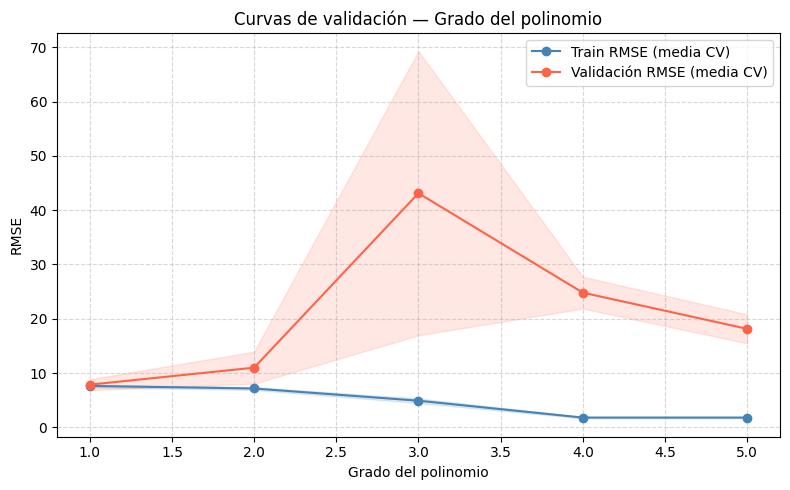


RMSE promedio por grado:
  Grado 1: Train=7.6146  Val=7.8496
  Grado 2: Train=7.1468  Val=10.9821
  Grado 3: Train=4.8964  Val=43.1198
  Grado 4: Train=1.7879  Val=24.8024
  Grado 5: Train=1.7879  Val=18.1383


In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(degrees, train_mean, 'o-', color='steelblue', label='Train RMSE (media CV)')
ax.fill_between(degrees,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(degrees, val_mean, 'o-', color='tomato', label='Validación RMSE (media CV)')
ax.fill_between(degrees,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='tomato')

ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('RMSE')
ax.set_title('Curvas de validación — Grado del polinomio')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nRMSE promedio por grado:")
for d, tm, vm in zip(degrees, train_mean, val_mean):
    print(f"  Grado {d}: Train={tm:.4f}  Val={vm:.4f}")


## 6. Modelos de regularización Ridge y Lasso

### 6.1 Ridge

In [24]:
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {
    'preprocessor__num__poly__degree': [1],       # lineal para esta actividad
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha':                    [0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator = pipeline_ridge,
    param_grid= param_grid_ridge,
    cv        = 5,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_ridge.fit(X_train, y_train)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...], 'preprocessor__num__poly__degree': [1], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [25]:
print("=== Mejores hiperparámetros Ridge ===")
print(f"  alpha:  {grid_ridge.best_params_['model__alpha']}")
print(f"  scaler: {grid_ridge.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_ridge.best_score_:.4f}")

y_pred_ridge = grid_ridge.best_estimator_.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"\n=== Ridge — Test ===")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  MAE:  {mae_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")


=== Mejores hiperparámetros Ridge ===
  alpha:  100
  scaler: RobustScaler()
  RMSE CV: 7.7656

=== Ridge — Test ===
  RMSE: 3.3069
  MAE:  1.7400
  R²:   0.2549


### 6.2 Lasso

In [26]:
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'preprocessor__num__poly__degree': [1],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha':                    [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(
    estimator = pipeline_lasso,
    param_grid= param_grid_lasso,
    cv        = 5,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_lasso.fit(X_train, y_train)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...], 'preprocessor__num__poly__degree': [1], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [27]:
print("=== Mejores hiperparámetros Lasso ===")
print(f"  alpha:  {grid_lasso.best_params_['model__alpha']}")
print(f"  scaler: {grid_lasso.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_lasso.best_score_:.4f}")

y_pred_lasso = grid_lasso.best_estimator_.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f"\n=== Lasso — Test ===")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  MAE:  {mae_lasso:.4f}")
print(f"  R²:   {r2_lasso:.4f}")


=== Mejores hiperparámetros Lasso ===
  alpha:  0.1
  scaler: RobustScaler()
  RMSE CV: 7.7298

=== Lasso — Test ===
  RMSE: 3.2862
  MAE:  1.6739
  R²:   0.2642


In [28]:
# Coeficientes Lasso — variables llevadas a cero
lasso_model = grid_lasso.best_estimator_.named_steps['model']
preprocessor_fitted = grid_lasso.best_estimator_.named_steps['preprocessor']

try:
    feature_names_num = preprocessor_fitted.transformers_[0][1].named_steps['poly'].get_feature_names_out(cols_numericas)
    feature_names_cat = preprocessor_fitted.transformers_[1][1].named_steps['onehot'].get_feature_names_out(cols_categoricas)
    feature_names_all = list(feature_names_num) + list(feature_names_cat)
except Exception:
    feature_names_all = [f'feature_{i}' for i in range(len(lasso_model.coef_))]

coef_df = pd.DataFrame({
    'Feature':     feature_names_all,
    'Coeficiente': lasso_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"Variables con coeficiente = 0: {(coef_df['Coeficiente'] == 0).sum()} de {len(coef_df)}")
print("\nTop 10 variables más relevantes:")
print(coef_df.head(10).to_string(index=False))


Variables con coeficiente = 0: 29 de 39

Top 10 variables más relevantes:
                       Feature   Coeficiente
                           BMI  2.170632e+00
             Diabetes Status_N -2.025108e+00
     Total Cholesterol (mg/dL)  1.277548e+00
                   Systolic BP  1.180183e+00
   Physical Activity Level_Low -2.095333e-01
Blood Pressure Category_Normal -1.692985e-01
              Age Group_Adulto -8.053798e-02
   Fasting Blood Sugar (mg/dL)  5.126806e-02
         BMI Category_Obesidad  8.041114e-03
             Diabetes Status_Y  9.380758e-16


## 7. Regresión polinomial con features derivadas y regularización

In [29]:
pipeline_poly_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_poly_ridge = {
    'preprocessor__num__poly__degree': [1, 2, 3],
    'preprocessor__num__scaler':       [StandardScaler(), RobustScaler()],
    'model__alpha':                    [0.01, 0.1, 1, 10, 100, 1000]
}

grid_poly_ridge = GridSearchCV(
    estimator = pipeline_poly_ridge,
    param_grid= param_grid_poly_ridge,
    cv        = 5,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_poly_ridge.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...], 'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), RobustScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [30]:
print("=== Mejores hiperparámetros Polinomial + Ridge ===")
print(f"  Grado:  {grid_poly_ridge.best_params_['preprocessor__num__poly__degree']}")
print(f"  Alpha:  {grid_poly_ridge.best_params_['model__alpha']}")
print(f"  Scaler: {grid_poly_ridge.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_poly_ridge.best_score_:.4f}")

y_pred_pr = grid_poly_ridge.best_estimator_.predict(X_test)
rmse_pr = np.sqrt(mean_squared_error(y_test, y_pred_pr))
mae_pr  = mean_absolute_error(y_test, y_pred_pr)
r2_pr   = r2_score(y_test, y_pred_pr)

print(f"\n=== Polinomial + Ridge — Test ===")
print(f"  RMSE: {rmse_pr:.4f}")
print(f"  MAE:  {mae_pr:.4f}")
print(f"  R²:   {r2_pr:.4f}")


=== Mejores hiperparámetros Polinomial + Ridge ===
  Grado:  1
  Alpha:  100
  Scaler: RobustScaler()
  RMSE CV: 7.7656

=== Polinomial + Ridge — Test ===
  RMSE: 3.3069
  MAE:  1.7400
  R²:   0.2549


In [31]:
# Recopilar RMSE CV (promedio ± std) y métricas de test de todos los modelos

def cv_stats(grid):
    best_idx = grid.best_index_
    mean = -grid.cv_results_['mean_test_score'][best_idx]
    std  =  grid.cv_results_['std_test_score'][best_idx]
    return mean, std

rmse_cv_poly,  std_cv_poly  = cv_stats(grid_search)
rmse_cv_ridge, std_cv_ridge = cv_stats(grid_ridge)
rmse_cv_lasso, std_cv_lasso = cv_stats(grid_lasso)
rmse_cv_pr,    std_cv_pr    = cv_stats(grid_poly_ridge)

tabla = pd.DataFrame({
    'Modelo':           ['Polinomial', 'Ridge', 'Lasso', 'Polinomial + Ridge'],
    'RMSE CV (media)':  [rmse_cv_poly, rmse_cv_ridge, rmse_cv_lasso, rmse_cv_pr],
    'RMSE CV (std)':    [std_cv_poly,  std_cv_ridge,  std_cv_lasso,  std_cv_pr],
    'RMSE Test':        [rmse_poly,    rmse_ridge,    rmse_lasso,    rmse_pr],
    'MAE Test':         [mae_poly,     mae_ridge,     mae_lasso,     mae_pr],
    'R² Test':          [r2_poly,      r2_ridge,      r2_lasso,      r2_pr],
})

tabla = tabla.round(4)
print(tabla.to_string(index=False))


            Modelo  RMSE CV (media)  RMSE CV (std)  RMSE Test  MAE Test  R² Test
        Polinomial           7.8496         0.9983     3.4069    1.8615   0.2091
             Ridge           7.7656         0.9866     3.3069    1.7400   0.2549
             Lasso           7.7298         1.0002     3.2862    1.6739   0.2642
Polinomial + Ridge           7.7656         0.9866     3.3069    1.7400   0.2549
